# Семинар 7. Семантическая сегментация Unet

### В этом задании Вам предстоит:
1. Реализовать архитектуру Unet на Keras
2. Обучить свою модель на небольшом датасете и сохранить её  

Источник: https://www.tensorflow.org/tutorials/images/segmentation

### Импорт библиотек и загрузка данных

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow_datasets as tfds

In [ ]:
data, info = tfds.load('oxford_iiit_pet:4.*.*', with_info=True)
train_dataset = data['train']
test_dataset = data['test']
print(info)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling C:\Users\alexm\tensorflow_datasets\oxford_iiit_pet\incomplete.76AJ92_4.0.0\oxford_iiit_pet-train.tfr…

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling C:\Users\alexm\tensorflow_datasets\oxford_iiit_pet\incomplete.76AJ92_4.0.0\oxford_iiit_pet-test.tfre…

Dataset oxford_iiit_pet downloaded and prepared to C:\Users\alexm\tensorflow_datasets\oxford_iiit_pet\4.0.0. Subsequent calls will reuse this data.
tfds.core.DatasetInfo(
    name='oxford_iiit_pet',
    full_name='oxford_iiit_pet/4.0.0',
    description="""
    The Oxford-IIIT pet dataset is a 37 category pet image dataset with roughly 200
    images for each class. The images have large variations in scale, pose and
    lighting. All images have an associated ground truth annotation of breed and
    species. Additionally, head bounding boxes are provided for the training split,
    allowing using this dataset for simple object detection tasks. In the test
    split, the bounding boxes are empty.
    """,
    homepage='http://www.robots.ox.ac.uk/~vgg/data/pets/',
    data_dir='C:\\Users\\alexm\\tensorflow_datasets\\oxford_iiit_pet\\4.0.0',
    file_format=tfrecord,
    download_size=773.52 MiB,
    dataset_size=773.68 MiB,
    features=FeaturesDict({
        'file_name': Text(shape=(),

### Визуализация изображений и масок

In [ ]:
def display(display_list):
  plt.figure(figsize=(15, 15))

  title = ['Input Image', 'True Mask', 'Predicted Mask']

  for i in range(len(display_list)):
    plt.subplot(1, len(display_list), i+1)
    plt.title(title[i])
    plt.imshow(tf.keras.utils.array_to_img(display_list[i]))
    plt.axis('off')
  plt.show()

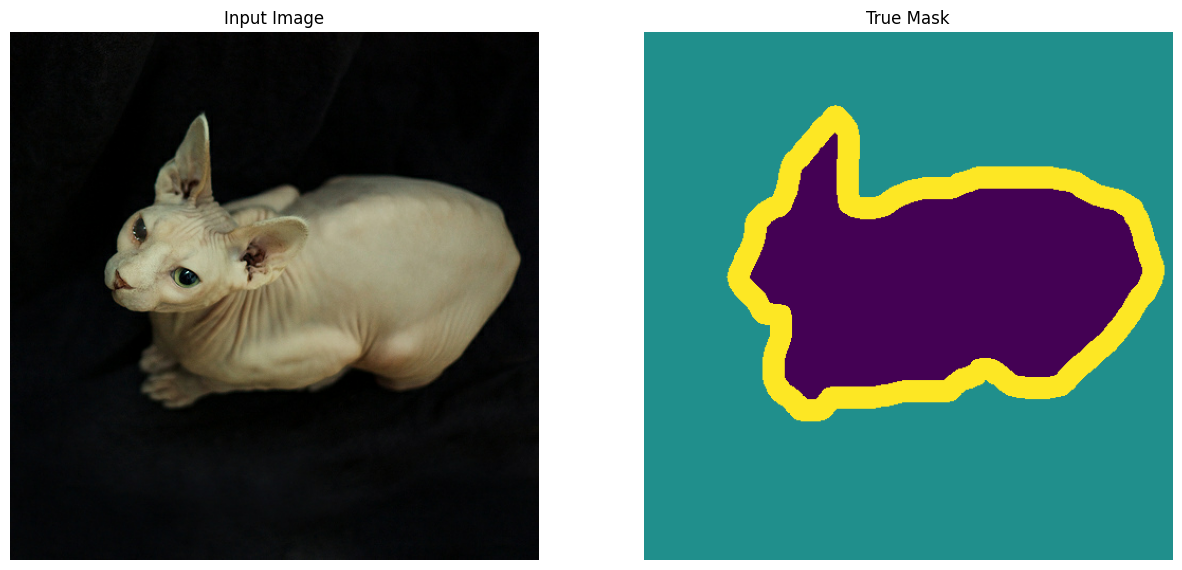

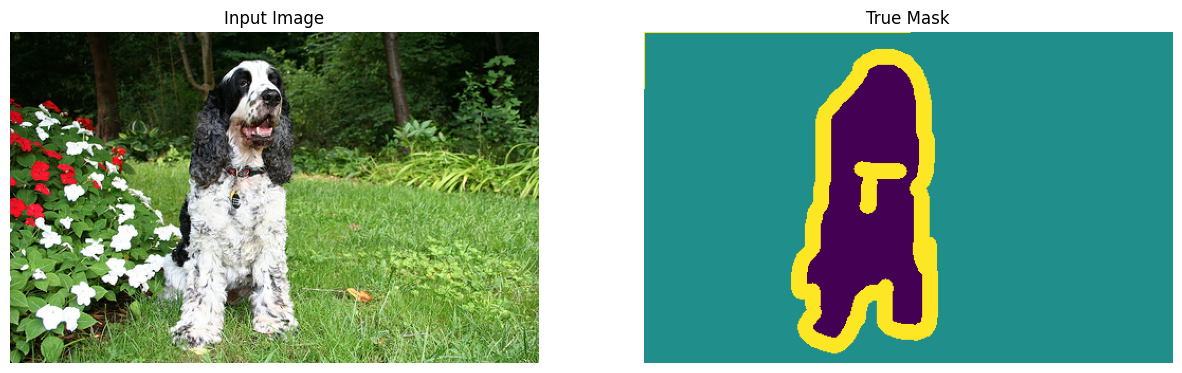

In [ ]:
for entity in train_dataset.take(2):
  sample_image, sample_mask = entity['image'], entity['segmentation_mask']
  display([sample_image, sample_mask])

### Операция Conv2DTranspose (Upconvolution, upsample)
https://arxiv.org/pdf/1603.07285v1.pdf

In [ ]:
x = np.ones((1,5,5,1))
out = tf.keras.layers.Conv2DTranspose(
    filters=1,
    kernel_size=(2,2),
    strides=2,
    kernel_initializer='ones')(x)

In [ ]:
out.numpy().reshape(10,10)

array([[1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.]], dtype=float32)

### Архитектура Unet 
<img src='https://raw.githubusercontent.com/shreyaspadhy/UNet-Zoo/master/unet.png'>

С помощью Functional API можно строить более гибкие архитектуры.  
Например, несколько слоев можно объединить друг с другом с помощью обычных python - функций. 

In [ ]:
def double_conv_block(x, n_filters):
    # Conv2D then ReLU activation
    x = tf.keras.layers.Conv2D(n_filters, 
                      kernel_size=3, 
                      padding = "same", 
                      activation = "relu", 
                      kernel_initializer = "he_normal")(x)
    # Conv2D then ReLU activation
    x = tf.keras.layers.Conv2D(n_filters, 
                      kernel_size=3,
                      padding = "same",
                      activation = "relu",
                      kernel_initializer = "he_normal")(x)
    return x

def downsample_block(x, n_filters):
    conv_features = double_conv_block(x, n_filters)
    p = tf.keras.layers.MaxPool2D(2)(conv_features)
    return conv_features, p

def upsample_block(x, conv_features, n_filters):
    # upsample
    x = tf.keras.layers.Conv2DTranspose(n_filters, 
                               kernel_size=3, 
                               strides=2, padding="same")(x)
    # concatenate
    x = tf.keras.layers.concatenate([x, conv_features])
    # Conv2D twice with ReLU activation
    x = double_conv_block(x, n_filters)
    return x

### Задание 1. Реализуйте архитектуру Unet на Keras 

Не забудьте про нормализацию входных данных!

In [ ]:
 # inputs
inputs = tf.keras.layers.Input(shape=(256,256,3))

# encoder: contracting path - downsample
# downsample
f1, p1 = downsample_block(inputs, 256)

# bottleneck
bottleneck = double_conv_block(p1, 1024)

# decoder: expanding path - upsample
#  upsample
u1 = upsample_block(bottleneck, f1, 256)

# outputs
outputs = tf.keras.layers.Conv2D(3, 1, padding="same", activation = "softmax")(u1)

# unet model with Keras Functional API
unet_model = tf.keras.Model(inputs, outputs, name="U-Net")

In [ ]:
unet_model.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"])

### Не забываем проверить модель на малой выборке данных 

In [ ]:
@tf.function
def resize_image_and_mask(example):
    image = tf.image.resize(example['image'], (256, 256))
    segmentation_mask =  tf.image.resize(example['segmentation_mask'], (256, 256)) - 1
    return image, segmentation_mask


In [ ]:
# resize and batch dataset  
small_data = train_dataset.map(resize_image_and_mask).take(2).batch(2).cache()
model_history = unet_model.fit(small_data, epochs=4)

Epoch 1/4
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step - accuracy: 0.6132 - loss: 40.1842
Epoch 2/4
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step - accuracy: 0.1667 - loss: 7296.5010
Epoch 3/4
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step - accuracy: 0.0839 - loss: 522.1907
Epoch 4/4
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step - accuracy: 0.5265 - loss: 10.2913


### Вопрос 1.

Чему равно матожидание начального значения segmentation CE_loss?  
**Ответ:** при равновероятном начальном предсказании по $C$ классам ожидаемый loss равен $\ln(C)$. В этой работе $C=3$, поэтому $\ln(3) \approx 1.10$.

### Задание 2. Обучите Unet и сохраните модель

In [ ]:
unet_model = tf.keras.Model(inputs, outputs, name="U-Net")
unet_model.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"])

In [ ]:
import os

os.makedirs("models", exist_ok=True)

# Save a checkpoint each epoch and keep the best model by val_loss.
checkpoint_cb = tf.keras.callbacks.ModelCheckpoint(
    filepath="models/unet_pet_model_epoch_{epoch:02d}.keras",
    monitor="val_loss",
    save_best_only=False,
    save_freq="epoch"
)

best_cb = tf.keras.callbacks.ModelCheckpoint(
    filepath="models/unet_pet_model_best.keras",
    monitor="val_loss",
    save_best_only=True
)

model_history = unet_model.fit(
    train_dataset.map(resize_image_and_mask).cache().batch(4).prefetch(tf.data.AUTOTUNE),
    epochs=10,
    callbacks=[checkpoint_cb, best_cb],
    validation_data=test_dataset.map(resize_image_and_mask).cache().batch(4).prefetch(tf.data.AUTOTUNE)
)

# Final model snapshot after training.
unet_model.save("models/unet_pet_model_final.keras")

Epoch 1/10
267/920 ━━━━━━━━━━━━━━━━━━━━ 1:55:08 11s/step - accuracy: 0.5534 - loss: 2.5829

KeyboardInterrupt: 

In [ ]:
loss = model_history.history['loss']
val_loss = model_history.history['val_loss']

plt.figure()
plt.plot(model_history.epoch, loss, 'r', label='Training loss')
plt.plot(model_history.epoch, val_loss, 'bo', label='Validation loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss Value')
plt.ylim([0, 1])
plt.legend()
plt.show()

### Задание 3. Визуализируйте предсказанные маски

In [ ]:
def show_prediction(model, dataset, num_samples=3):
    for image_batch, mask_batch in dataset.take(1):
        preds = model.predict(image_batch[:num_samples], verbose=0)
        pred_masks = tf.argmax(preds, axis=-1)
        pred_masks = tf.expand_dims(pred_masks, axis=-1)

        for i in range(num_samples):
            plt.figure(figsize=(12, 4))

            plt.subplot(1, 3, 1)
            plt.title("Image")
            plt.imshow(image_batch[i])
            plt.axis("off")

            plt.subplot(1, 3, 2)
            plt.title("True mask")
            plt.imshow(tf.squeeze(mask_batch[i]), cmap="viridis")
            plt.axis("off")

            plt.subplot(1, 3, 3)
            plt.title("Predicted mask")
            plt.imshow(tf.squeeze(pred_masks[i]), cmap="viridis")
            plt.axis("off")

            plt.tight_layout()
            plt.show()

show_prediction(
    model=unet_model,
    dataset=test_dataset.map(resize_image_and_mask).batch(4),
    num_samples=3
)